In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# Configuração de visualização
sns.set_style("whitegrid")

In [3]:
# Defina aqui os nomes dos seus arquivos
caminho_treino = '../database/treino/features_full.csv'
caminho_validacao = '../database/validacao/features_full.csv'
caminho_teste = '../database/teste/features_full.csv'

# Caminhos de Saída (Ajuste se necessário para caminhos absolutos ou relativos)
caminho_saida = './out' 
caminho_modelo = './models'

# Cria os diretórios se não existirem
os.makedirs(caminho_saida, exist_ok=True)
os.makedirs(caminho_modelo, exist_ok=True)

# Mapeamento de classes
group_map = {'NonDemented': 0, 'Demented': 1} 

features = [
    'Ventricle_Area', 'Ventricle_Perimeter', 'Ventricle_Circularity', 
    'Ventricle_Eccentricity', 'Ventricle_Solidity', 'Ventricle_MajorAxisLength'
]

def processar_csv(caminho):
    # Lê com separador ; e decimal ,
    df = pd.read_csv(caminho, sep=';', decimal=',')
    
    # Codifica o alvo (Target Classification)
    # Se houver valores fora do map, eles viram NaN e são removidos no dropna
    df['Group_Encoded'] = df['Group'].map(group_map)
    
    # Remove nulos para evitar erros nos modelos
    df = df.dropna()
    
    # Separa X (features) e y (targets)
    X = df[features]
    y_class = df['Group_Encoded'] # Target Classificação
    y_reg = df['Age']             # Target Regressão
    
    return X, y_class, y_reg

# Processar os três arquivos separadamente
print("Carregando Treino...")
X_train, y_class_train, y_reg_train = processar_csv(caminho_treino)

print("Carregando Validação...")
X_val, y_class_val, y_reg_val = processar_csv(caminho_validacao)

print("Carregando Teste...")
X_test, y_class_test, y_reg_test = processar_csv(caminho_teste)

print(f"\nRegistros de Treino: {len(X_train)}")
print(f"Registros de Validação: {len(X_val)}")
print(f"Registros de Teste: {len(X_test)}")

Carregando Treino...
Carregando Validação...
Carregando Teste...

Registros de Treino: 239
Registros de Validação: 58
Registros de Teste: 76


Modelo de classificação salvo em: ./models/linear_classifier.pkl

Limiar Ótimo Encontrado no Set de Validação: 0.66 (Acurácia de 0.5862)
Limiar ótimo salvo em: ./models/optimal_threshold.pkl

### Resultados da Classificação (Linear Regression com Limiar Otimizado) ###
Acurácia Final (Teste): 0.5395

Relatório de Classificação (Teste):
              precision    recall  f1-score   support

 NonDemented       0.53      1.00      0.70        40
    Demented       1.00      0.03      0.05        36

    accuracy                           0.54        76
   macro avg       0.77      0.51      0.37        76
weighted avg       0.75      0.54      0.39        76

Gráfico de confusão salvo em: ./out/confusion_matrix_linear_optimized.png


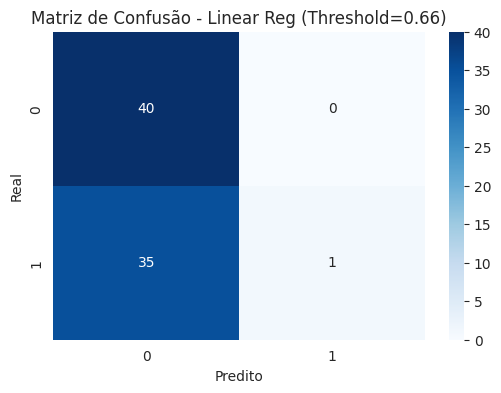

In [ ]:
# --- TAREFA 1: CLASSIFICAÇÃO ---

# Instanciar e treinar o Regressor Linear
lin_reg_classifier = LinearRegression()
lin_reg_classifier.fit(X_train, y_class_train)

# Salvar o modelo
modelo_path_class = os.path.join(caminho_modelo, 'linear_classifier.pkl')
joblib.dump(lin_reg_classifier, modelo_path_class)
print(f"Modelo de classificação salvo em: {modelo_path_class}")

# Predição
raw_predictions_val = lin_reg_classifier.predict(X_val)
best_threshold = 0.5
best_accuracy = 0

# Testar limiares de 0.00 a 1.00 com incremento de 0.01
for threshold in np.arange(0.00, 1.01, 0.01):
    temp_preds = [1 if val >= threshold else 0 for val in raw_predictions_val]
    current_accuracy = accuracy_score(y_class_val, temp_preds)
    
    if current_accuracy > best_accuracy:
        best_accuracy = current_accuracy
        best_threshold = threshold

print(f"\nLimiar Ótimo Encontrado no Set de Validação: {best_threshold:.2f} (Acurácia de {best_accuracy:.4f})")

# Salvar o limiar ótimo para uso na função de inferência
threshold_path = os.path.join(caminho_modelo, 'optimal_threshold.pkl')
joblib.dump(best_threshold, threshold_path)
print(f"Limiar ótimo salvo em: {threshold_path}")


# ----------------------------------------------
# 2. Avaliação Final no Set de Teste com o Limiar Ótimo
# ----------------------------------------------
raw_predictions_test = lin_reg_classifier.predict(X_test)
class_predictions_test = [1 if val >= best_threshold else 0 for val in raw_predictions_test]

# Avaliação
print("\n### Resultados da Classificação (Linear Regression com Limiar Otimizado) ###")
print(f"Acurácia Final (Teste): {accuracy_score(y_class_test, class_predictions_test):.4f}")
print("\nRelatório de Classificação (Teste):")
print(classification_report(y_class_test, class_predictions_test, target_names=['NonDemented', 'Demented']))

# Matriz de Confusão e Salvamento da Imagem
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_class_test, class_predictions_test), annot=True, fmt='d', cmap='Blues')
plt.title(f'Matriz de Confusão - Linear Reg (Threshold={best_threshold:.2f})')
plt.ylabel('Real')
plt.xlabel('Predito')

# Salvar imagem
img_path_class = os.path.join(caminho_saida, 'sl_cm_linear.png') 
plt.savefig(img_path_class, dpi=300, bbox_inches='tight')
print(f"Gráfico de confusão salvo em: {img_path_class}")

plt.show()

Modelo de regressão salvo em: ./models/xgboost_regressor.pkl

### Resultados da Regressão de Idade (XGBoost) ###
Erro Médio Absoluto (MAE): 6.45 anos
Raiz do Erro Quadrático Médio (RMSE): 7.93 anos
Coeficiente de Determinação (R²): -0.1830
Gráfico de dispersão salvo em: ./out/regression_scatter_xgboost.png


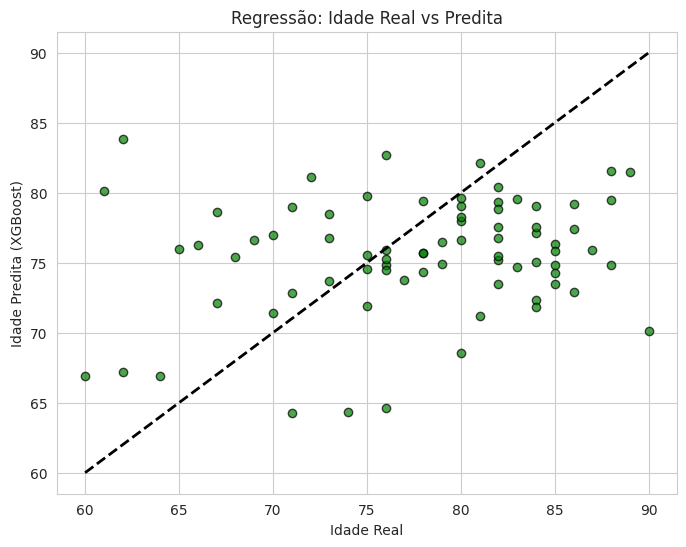

In [6]:
# CÉLULA 4: Regressão (Salvar Gráfico e Modelo)

# Não é mais necessário importar EarlyStopping
# from xgboost.callback import EarlyStopping 

# --- TAREFA 2: REGRESSÃO ---

# Instanciar e treinar o XGBoost Regressor
xgb_regressor = XGBRegressor(
    objective='reg:squarederror', 
    n_estimators=500, 
    learning_rate=0.05, 
    max_depth=5, 
    random_state=42
)

# CORREÇÃO FINAL: Remoção de todos os argumentos problemáticos (eval_set, callbacks, verbose)
# O modelo treinará por 500 épocas.
xgb_regressor.fit(
    X_train, y_reg_train
)

# Salvar o modelo
modelo_path_reg = os.path.join(caminho_modelo, 'xgboost_regressor.pkl')
joblib.dump(xgb_regressor, modelo_path_reg)
print(f"Modelo de regressão salvo em: {modelo_path_reg}")

# Predição
age_predictions = xgb_regressor.predict(X_test)

# Métricas
mae = mean_absolute_error(y_reg_test, age_predictions)
rmse = np.sqrt(mean_squared_error(y_reg_test, age_predictions))
r2 = r2_score(y_reg_test, age_predictions)

print("\n### Resultados da Regressão de Idade (XGBoost) ###")
print(f"Erro Médio Absoluto (MAE): {mae:.2f} anos")
print(f"Raiz do Erro Quadrático Médio (RMSE): {rmse:.2f} anos")
print(f"Coeficiente de Determinação (R²): {r2:.4f}")

# Gráfico de Dispersão e Salvamento da Imagem
plt.figure(figsize=(8, 6))
plt.scatter(y_reg_test, age_predictions, alpha=0.7, color='green', edgecolors='k')
plt.plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()], 'k--', lw=2)
plt.xlabel('Idade Real')
plt.ylabel('Idade Predita (XGBoost)')
plt.title('Regressão: Idade Real vs Predita')

# Salvar imagem
img_path_reg = os.path.join(caminho_saida, 'regression_scatter_xgboost.png')
plt.savefig(img_path_reg, dpi=300, bbox_inches='tight')
print(f"Gráfico de dispersão salvo em: {img_path_reg}")

plt.show()

In [7]:
def diagnostico_paciente(dados_paciente):
    """
    Recebe um dicionário ou lista com as features do paciente e retorna o diagnóstico e idade estimada.
    Ordem esperada: Ventricle_Area, Ventricle_Perimeter, Ventricle_Circularity, 
                    Ventricle_Eccentricity, Ventricle_Solidity, Ventricle_MajorAxisLength
    """
    
    # Carregar modelos salvos (garante que estamos usando a versão persistida)
    try:
        clf_model = joblib.load(os.path.join(caminho_modelo, 'linear_classifier.pkl'))
        reg_model = joblib.load(os.path.join(caminho_modelo, 'xgboost_regressor.pkl'))
    except FileNotFoundError:
        print("Erro: Modelos não encontrados. Execute o treinamento primeiro.")
        return

    # Converter entrada para DataFrame (necessário para manter nomes das colunas corretos para o XGBoost)
    # features é a lista definida na Célula 2
    df_input = pd.DataFrame([dados_paciente], columns=features)
    
    # 1. Classificação
    raw_class = clf_model.predict(df_input)[0]
    # Lógica do Threshold 0.5
    diagnostico = "Demented" if raw_class >= 0.5 else "NonDemented"
    confianca = raw_class if raw_class >= 0.5 else (1 - raw_class) # "Pseudo-probabilidade"
    
    # 2. Regressão (Idade)
    idade_estimada = reg_model.predict(df_input)[0]
    
    print("--- Resultado da Análise ---")
    print(f"Input Features: {dados_paciente}")
    print(f"Diagnóstico Previsto: {diagnostico} (Score Bruto: {raw_class:.4f})")
    print(f"Idade Estimada: {idade_estimada:.1f} anos")
    
    return diagnostico, idade_estimada

# --- Exemplo de Uso ---
# Pegando um paciente aleatório do teste para simular uma nova entrada
paciente_exemplo = X_test.iloc[0].values.tolist()

print("Testando com um paciente real da base de teste:")
diag, idade = diagnostico_paciente(paciente_exemplo)

print(f"\n(Valores Reais -> Diagnóstico: {y_class_test.iloc[0]}, Idade: {y_reg_test.iloc[0]})")

Testando com um paciente real da base de teste:
--- Resultado da Análise ---
Input Features: [4135.0, 573.5706345359769, 0.1579470653562626, 0.8171864790534409, 0.5077357563850687, 130.99488873203646]
Diagnóstico Previsto: NonDemented (Score Bruto: 0.4801)
Idade Estimada: 71.9 anos

(Valores Reais -> Diagnóstico: 1, Idade: 75)
